In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from nltk.corpus import stopwords
import seaborn as sns

import matplotlib.pyplot as plt

import joblib

In [2]:

# Chargement
df = pd.read_csv("../data/lille_2022.csv", sep=',')

# Filtrage 4 pièces uniquement
df = df[df['Nombre pieces principales'] == 4]

In [3]:
df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,prix_m2
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,05/01/2022,Vente,...,0,1.0,Maison,NaN,165.0,4.0,S,NaN,121.0,1848.484848
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2022,Vente,...,1,2.0,Appartement,NaN,92.0,4.0,NaN,NaN,NaN,3989.130435
26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2022,Vente,...,2,2.0,Appartement,NaN,70.0,4.0,NaN,NaN,NaN,2428.571429
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,04/01/2022,Vente,...,2,2.0,Appartement,NaN,105.0,4.0,NaN,NaN,NaN,3383.809524
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2022,Vente,...,1,2.0,Appartement,NaN,120.0,4.0,NaN,NaN,NaN,3937.500000


In [4]:
colonnes_utiles = [
    'Surface reelle bati',
    'Nombre pieces principales',
    'Type local',
    'Surface terrain',
    'Nombre de lots',
    'Valeur fonciere',
    'prix_m2',
]

df = df[colonnes_utiles]

In [5]:
df.corr

<bound method DataFrame.corr of        Surface reelle bati  Nombre pieces principales   Type local  \
18                   165.0                        4.0       Maison   
23                    92.0                        4.0  Appartement   
26                    70.0                        4.0  Appartement   
58                   105.0                        4.0  Appartement   
62                   120.0                        4.0  Appartement   
...                    ...                        ...          ...   
11316                103.0                        4.0  Appartement   
11328                117.0                        4.0  Appartement   
11351                 78.0                        4.0  Appartement   
11352                 72.0                        4.0       Maison   
11353                 72.0                        4.0       Maison   

       Surface terrain  Nombre de lots  Valeur fonciere      prix_m2  
18               121.0               0         305000.0 

In [6]:
df = df.dropna()

In [7]:
# Nettoyage des données null
df.isna().sum()

Surface reelle bati          0
Nombre pieces principales    0
Type local                   0
Surface terrain              0
Nombre de lots               0
Valeur fonciere              0
prix_m2                      0
dtype: int64

In [8]:
# Création des deux sous-ensembles
df_apparts = df[df['Type local'] == 'Appartement'].copy()
df_maisons = df[df['Type local'] == 'Maison'].copy()

In [9]:
# Suppression des NaN restants
#df_apparts.dropna(inplace=True)
#df_maisons.dropna(inplace=True)

# Filtrage valeurs aberrantes
def nettoyer_outliers(df, min_m2=1000, max_m2=10000):
    return df[(df['prix_m2'] > min_m2) & (df['prix_m2'] < max_m2)]

#df_apparts = nettoyer_outliers(df_apparts)
#df_maisons = nettoyer_outliers(df_maisons)


In [10]:
df_apparts.head(10)

,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
394,116.0,4.0,Appartement,155.0,0,170000.0,1465.517241
575,170.0,4.0,Appartement,221.0,0,520000.0,3058.823529
940,53.0,4.0,Appartement,105.0,0,1470000.0,27735.849057
1249,65.0,4.0,Appartement,176.0,0,600000.0,9230.769231
1251,65.0,4.0,Appartement,176.0,0,600000.0,9230.769231
1252,65.0,4.0,Appartement,176.0,0,600000.0,9230.769231
1253,65.0,4.0,Appartement,176.0,0,600000.0,9230.769231
1525,72.0,4.0,Appartement,59.0,0,30000.0,416.666667
1529,72.0,4.0,Appartement,59.0,0,30000.0,416.666667
1624,130.0,4.0,Appartement,1207.0,0,1200000.0,9230.769231


In [11]:
df_maisons.head(10)

,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
18,165.0,4.0,Maison,121.0,0,305000.0,1848.484848
65,64.0,4.0,Maison,127.0,0,226900.0,3545.312500
161,70.0,4.0,Maison,192.0,0,205890.0,2941.285714
168,62.0,4.0,Maison,96.0,0,159500.0,2572.580645
176,72.0,4.0,Maison,135.0,0,259900.0,3609.722222
231,80.0,4.0,Maison,182.0,0,220000.0,2750.000000
312,65.0,4.0,Maison,47.0,0,203400.0,3129.230769
365,88.0,4.0,Maison,117.0,0,285500.0,3244.318182
379,93.0,4.0,Maison,131.0,0,284800.0,3062.365591
380,123.0,4.0,Maison,153.0,0,250000.0,2032.520325


In [12]:
df_apparts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 394 to 10447
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Surface reelle bati        49 non-null     float64
 1   Nombre pieces principales  49 non-null     float64
 2   Type local                 49 non-null     object 
 3   Surface terrain            49 non-null     float64
 4   Nombre de lots             49 non-null     int64  
 5   Valeur fonciere            49 non-null     float64
 6   prix_m2                    49 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 3.1+ KB


In [13]:
df_maisons.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340 entries, 18 to 11353
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Surface reelle bati        340 non-null    float64
 1   Nombre pieces principales  340 non-null    float64
 2   Type local                 340 non-null    object 
 3   Surface terrain            340 non-null    float64
 4   Nombre de lots             340 non-null    int64  
 5   Valeur fonciere            340 non-null    float64
 6   prix_m2                    340 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 21.2+ KB


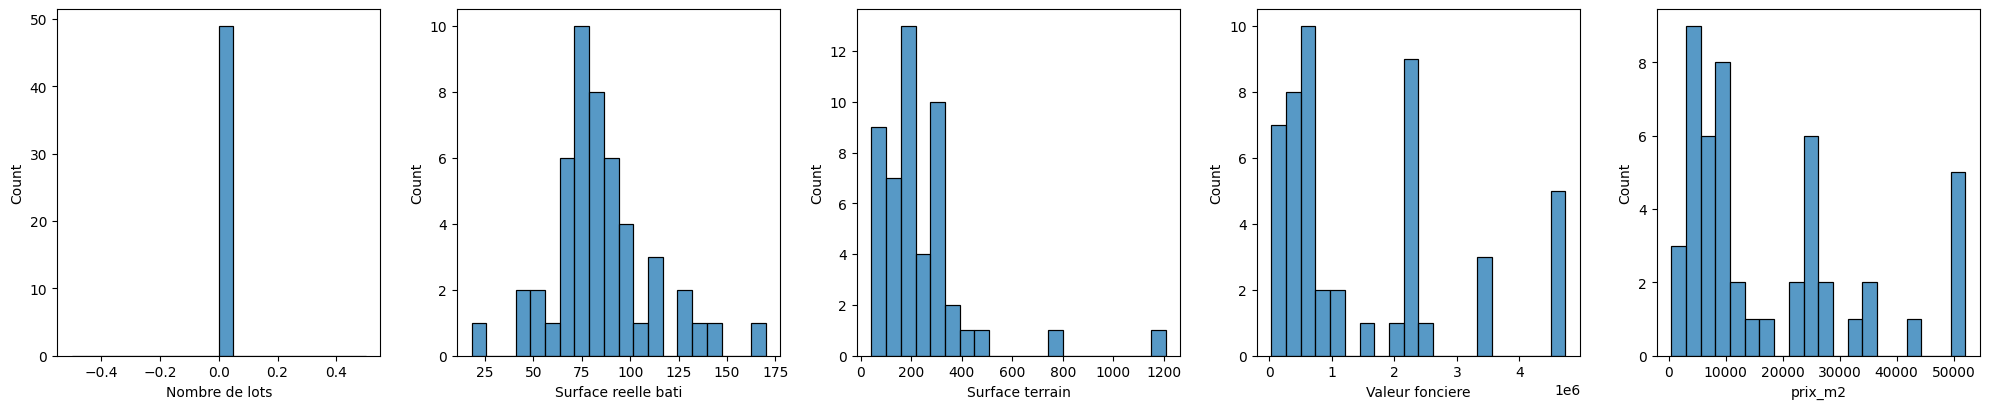

In [14]:
# Visualisation des données pour les appartements
columns = ['Nombre de lots', 'Surface reelle bati', 'Surface terrain', 'Valeur fonciere', 'prix_m2']

plt.figure(figsize=(24,24))
for i, col in enumerate(columns, 1):
    plt.subplot(6, 6, i)
    sns.histplot(df_apparts[col], bins=20)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


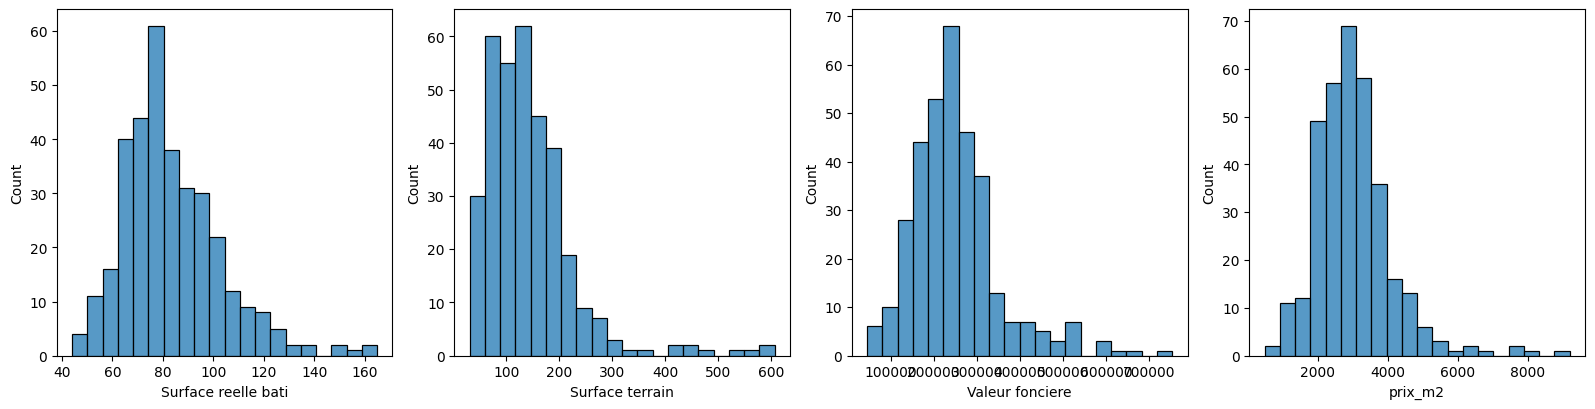

In [15]:
# Visualisation des données pour les maisons
columns = ['Surface reelle bati', 'Surface terrain', 'Valeur fonciere', 'prix_m2']

plt.figure(figsize=(24,24))
for i, col in enumerate(columns, 1):
    plt.subplot(6, 6, i)
    sns.histplot(df_maisons[col], bins=20)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [16]:
def remove_outliers_iqr(df, column):
    """
    Supprime les valeurs aberrantes d'une colonne numérique dans un DataFrame,
    en utilisant la méthode de l'IQR. Modifie le DataFrame en place et affiche
    le nombre de lignes supprimées.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_indices = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index
    nb_outliers = len(outlier_indices)

    df.drop(outlier_indices, inplace=True)
    print(f"{nb_outliers} valeur(s) aberrante(s) supprimée(s) dans la colonne '{column}'.")

In [17]:
print("Outliers surface :\n", remove_outliers_iqr(df_apparts, "Surface reelle bati"), "\n")
print("--"*50)
print("Outliers surface :\n", remove_outliers_iqr(df_maisons, "Surface reelle bati"), "\n")

5 valeur(s) aberrante(s) supprimée(s) dans la colonne 'Surface reelle bati'.
Outliers surface :
 None 

----------------------------------------------------------------------------------------------------
9 valeur(s) aberrante(s) supprimée(s) dans la colonne 'Surface reelle bati'.
Outliers surface :
 None 



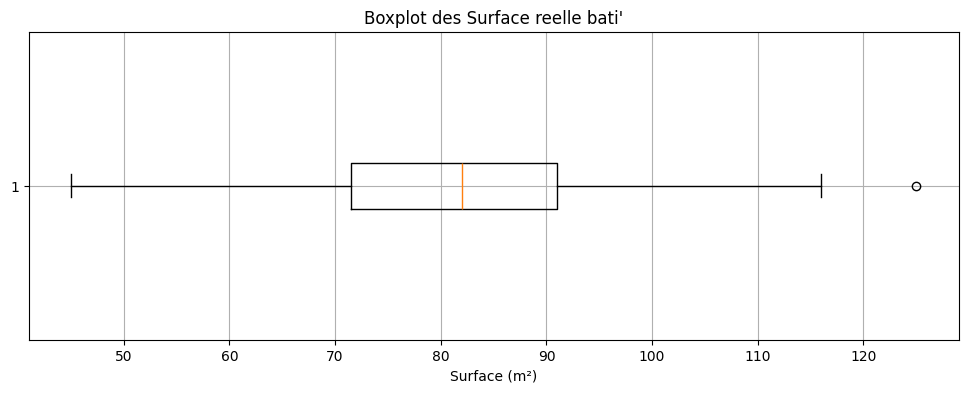

In [18]:
# Boxplot des surfaces pour les appartements
plt.figure(figsize=(12, 4))
plt.boxplot(df_apparts['Surface reelle bati'], vert=False)
plt.title("Boxplot des Surface reelle bati'")
plt.xlabel("Surface (m²)")
plt.grid(True)
plt.show()

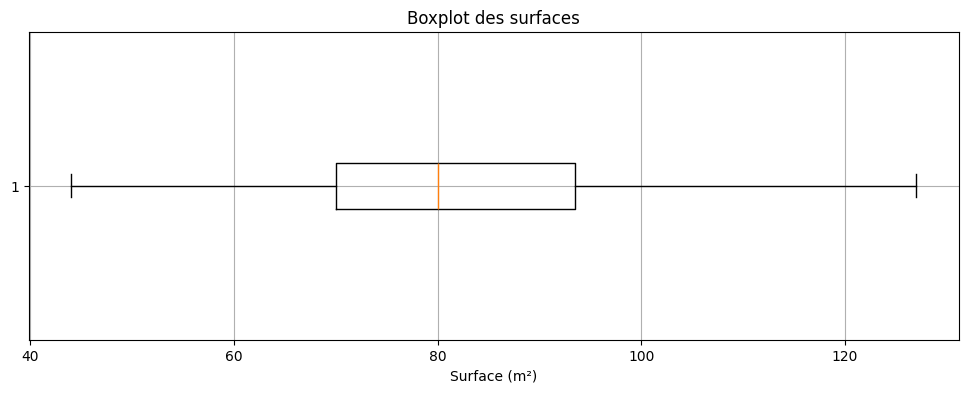

In [19]:
# Boxplot des surfaces pour les maisons
plt.figure(figsize=(12, 4))
plt.boxplot(df_maisons['Surface reelle bati'], vert=False)
plt.title("Boxplot des surfaces")
plt.xlabel("Surface (m²)")
plt.grid(True)
plt.show()

In [20]:
from pandas import DataFrame

def create_pipeline(data: DataFrame, col_x: list[str], col_y: list[str], model, name):
    """
    Crée un pipeline de traitement des données et d'entraînement du modèle.

    Paramètres :
    - data : DataFrame contenant les données
    - col_x : liste des noms des colonnes explicatives
    - col_y : nom de la colonne cible (string ou liste avec 1 élément)
    - model : instance d'un modèle de régression (ex: DecisionTreeRegressor)
    """
    X = data[col_x].values 
    
    y = data[col_y].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler_X = StandardScaler() # Initialisation d’un standardiseur pour la variable explicative X
    scaler_y = StandardScaler() # Initialisation d’un standardiseur pour la variable cible y

    # Apprentissage des paramètres (moyenne, écart-type) sur X_train et transformation des données
    X_train_scaled = scaler_X.fit_transform(X_train)

    # Apprentissage des paramètres sur y_train et transformation des données
    y_train_scaled = scaler_y.fit_transform(y_train)

    # Transformation de X_test à l’aide des paramètres appris sur X_train (pas de fit ici)
    X_test_scaled = scaler_X.transform(X_test)

    # Transformation de y_test à l’aide des paramètres appris sur y_train (pas de fit ici non plus)
    y_test_scaled = scaler_y.transform(y_test)
    
    model.fit(X_train_scaled, y_train_scaled)

    save_model(model, scaler_X, scaler_y, name)

    return (X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, model)

In [21]:
def save_model(model, scaler_X, scaler_y, filename: str):
    """
    Enregistre le modèle dans un fichier.
    
    Paramètres :
    - model : le modèle à enregistrer
    - filename : nom du fichier dans lequel enregistrer le modèle
    """
    joblib.dump(model, f"../models/{filename.lower()}.pkl")
    joblib.dump(scaler_X, f"../models/{filename}_scaler_X.pkl")
    joblib.dump(scaler_y, f"../models/{filename}_scaler_y.pkl")
    print(f"Modèle enregistré dans {filename}") 

# Creation des Model

### LinearRegression

In [22]:
from sklearn.linear_model import LinearRegression

X_train_scaled_line_maison, y_train_scaled_line_maison, X_test_scaled_line_maison, y_test_scaled_line_maison, model_line_maison = create_pipeline(df_maisons, ['Nombre de lots', 'Surface reelle bati'], ['prix_m2'], LinearRegression(), 'linear_regression_maison')
X_train_scaled_line_apart,  y_train_scaled_line_apart, X_test_scaled_line_apart, y_test_scaled_line_apart, model_line_apart     = create_pipeline(df_apparts, ['Nombre de lots', 'Surface reelle bati'], ['prix_m2'], LinearRegression(), 'linear_regression_apart')

Modèle enregistré dans linear_regression_maison
Modèle enregistré dans linear_regression_apart


### DecisionTreeRegressor 

In [23]:
from sklearn.tree import DecisionTreeRegressor

X_train_scaled_tree_maison, y_train_scaled_tree_maison, X_test_scaled_tree_maison, y_test_scaled_tree_maison, model_tree_maison = create_pipeline(df_maisons, ['Nombre de lots', 'Surface reelle bati'], ['prix_m2'], DecisionTreeRegressor(), 'decision_tree_regressor_maison')
X_train_scaled_tree_apart, y_train_scaled_tree_apart, X_test_scaled_tree_apart, y_test_scaled_tree_apart, model_tree_apart      = create_pipeline(df_apparts, ['Nombre de lots', 'Surface reelle bati'], ['prix_m2'], DecisionTreeRegressor(), 'decision_tree_regressor_apart')


Modèle enregistré dans decision_tree_regressor_maison
Modèle enregistré dans decision_tree_regressor_apart


### RandomForestRegressor

In [24]:
from sklearn.ensemble import RandomForestRegressor

X_train_scaled_forest_maison, y_train_scaled_forest_maison, X_test_scaled_forest_maison, y_test_scaled_forest_maison, model_forest_maison  = create_pipeline(df_maisons, ['Nombre de lots', 'Surface reelle bati'], ['prix_m2'], RandomForestRegressor(), 'random_forest_regressor_maison')
X_train_scaled_forest_apart, y_train_scaled_forest_apart, X_test_scaled_forest_apart, y_test_scaled_forest_apart, model_forest_apart   = create_pipeline(df_apparts, ['Nombre de lots', 'Surface reelle bati'], ['prix_m2'], RandomForestRegressor(), 'random_forest_regressor_apart')

Modèle enregistré dans random_forest_regressor_maison
Modèle enregistré dans random_forest_regressor_apart


/Users/shooterdev/Lab/PycharmProjects/Simplon/IA&Immobilier/.venv/lib/python3.10/site-packages/sklearn/base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/shooterdev/Lab/PycharmProjects/Simplon/IA&Immobilier/.venv/lib/python3.10/site-packages/sklearn/base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# Visualisation Des Jeux De Donnees

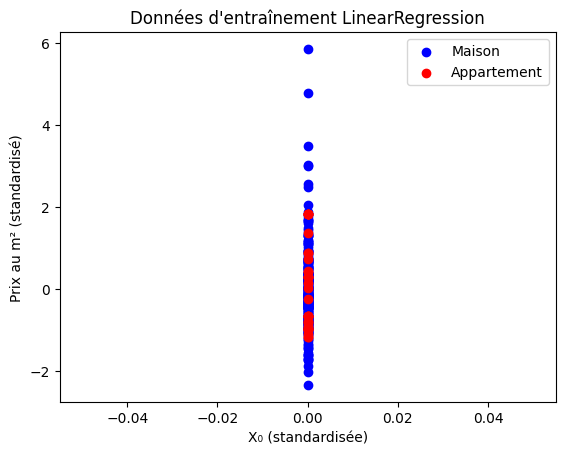

In [25]:
# Tracé des points d'entraînement
plt.scatter(X_train_scaled_line_maison[:, 0] , y_train_scaled_line_maison.ravel() , color='blue', label='Maison')
plt.scatter(X_train_scaled_line_apart[:, 0] , y_train_scaled_line_apart.ravel() , color='red', label='Appartement')
plt.title("Données d'entraînement LinearRegression")
plt.xlabel("X₀ (standardisée)")
plt.ylabel("Prix au m² (standardisé)")
plt.legend()
plt.show()

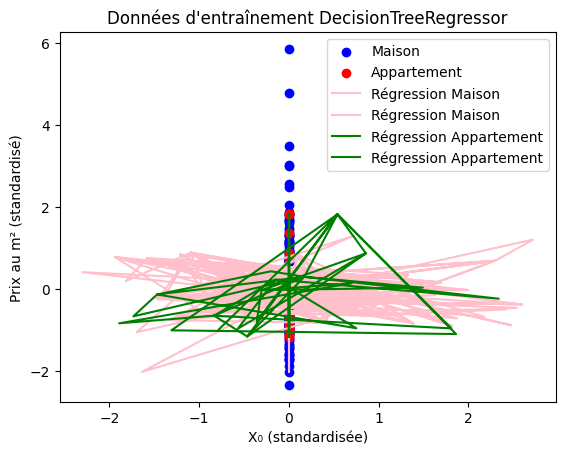

In [26]:

# Tracé des points d'entraînement
y_train_pred_scaled_tree_maison = model_tree_maison.predict(X_train_scaled_tree_maison)
y_train_pred_scaled_tree_apart = model_tree_apart.predict(X_train_scaled_tree_apart)

plt.scatter(X_train_scaled_tree_maison[:, 0] , y_train_scaled_tree_maison.ravel() , color='blue', label='Maison')
plt.scatter(X_train_scaled_tree_apart[:, 0] , y_train_scaled_tree_apart.ravel() , color='red', label='Appartement')

plt.plot(X_train_scaled_tree_maison, y_train_pred_scaled_tree_maison, color='pink', label='Régression Maison')
plt.plot(X_train_scaled_tree_apart, y_train_pred_scaled_tree_apart, color='green', label='Régression Appartement')

plt.title("Données d'entraînement DecisionTreeRegressor")
plt.xlabel("X₀ (standardisée)")
plt.ylabel("Prix au m² (standardisé)")
plt.legend()
plt.show()

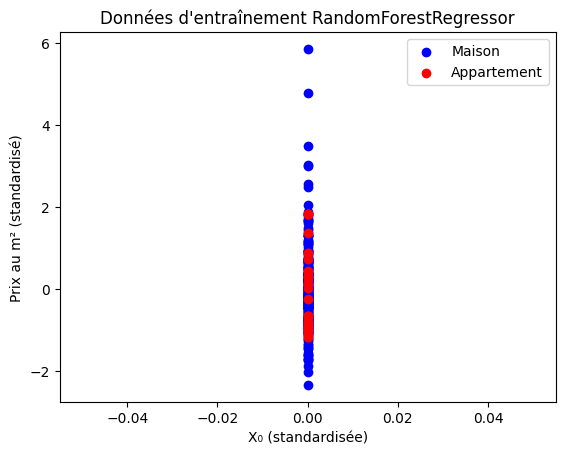

In [27]:
# Tracé des points d'entraînement
plt.scatter(X_train_scaled_forest_maison[:, 0] , y_train_scaled_forest_maison.ravel() , color='blue', label='Maison')
plt.scatter(X_train_scaled_forest_apart[:, 0] , y_train_scaled_forest_apart.ravel() , color='red', label='Appartement')
plt.title("Données d'entraînement RandomForestRegressor")
plt.xlabel("X₀ (standardisée)")
plt.ylabel("Prix au m² (standardisé)")
plt.legend()
plt.show()

## Score

In [28]:

import numpy as np

In [29]:
def evaluate_and_plot(name: str, model, X_test_scaled, y_test_scaled):
    """
    Évalue un modèle de régression et affiche les prédictions par rapport aux vraies valeurs.

    Paramètres :
    - name : nom du modèle
    - model : modèle entraîné
    - X_test_scaled : variables explicatives test standardisées
    - y_test_scaled : cible test standardisée
    """
    # Prédiction
    y_pred_scaled = model.predict(X_test_scaled)

    # Évaluation
    mse = mean_squared_error(y_test_scaled, y_pred_scaled)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_scaled, y_pred_scaled)

    print(f"\n📊 {name} — Évaluation du modèle :")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    # Affichage graphique
    plt.figure(figsize=(8, 6))
    plt.scatter(X_test_scaled[:, 0], y_test_scaled, color='blue', label='Valeur cible')
    plt.scatter(X_test_scaled[:, 0], y_pred_scaled, color='green', label='Prédiction')
    plt.title(f"{name} — Valeurs réelles vs. Prédictions")
    plt.xlabel("Surface (standardisée)")
    plt.ylabel("Prix au m² (standardisé)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Linear Regression — Maison


📊 Linear Regression — Maison — Évaluation du modèle :
MSE  : 1.4488
RMSE : 1.2036
R²   : -0.0062


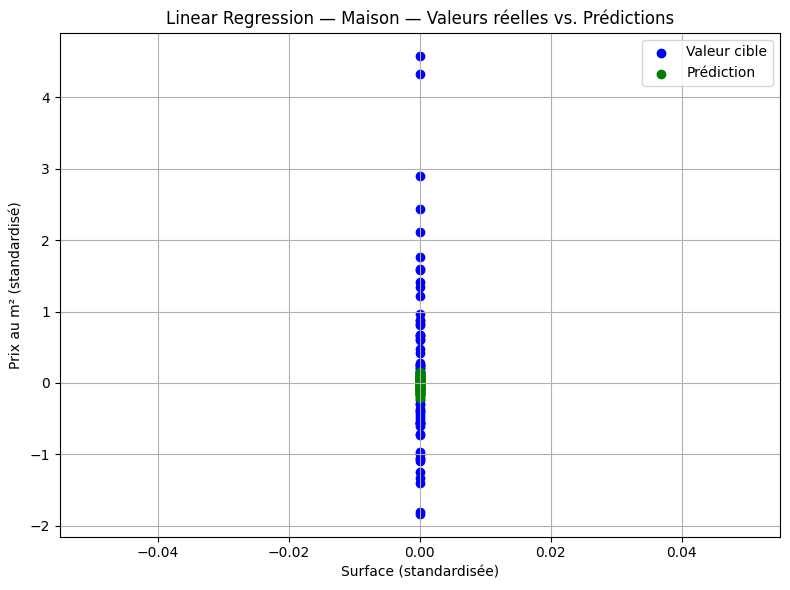

In [30]:
evaluate_and_plot("Linear Regression — Maison", model_line_maison, X_test_scaled_line_maison, y_test_scaled_line_maison)

## Linear Regression — Appartement


📊 Linear Regression — Appartement — Évaluation du modèle :
MSE  : 0.5372
RMSE : 0.7329
R²   : -1.7352


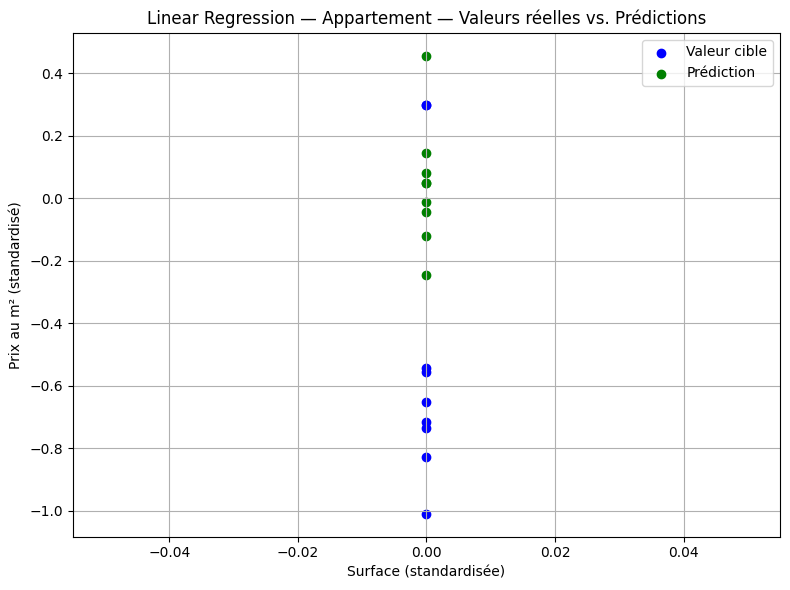

In [31]:
evaluate_and_plot("Linear Regression — Appartement", model_line_apart, X_test_scaled_line_apart, y_test_scaled_line_apart)

## Decision Tree Regressor — Appartement


📊 Decision Tree Regressor — Maison — Évaluation du modèle :
MSE  : 1.8008
RMSE : 1.3419
R²   : -0.2507


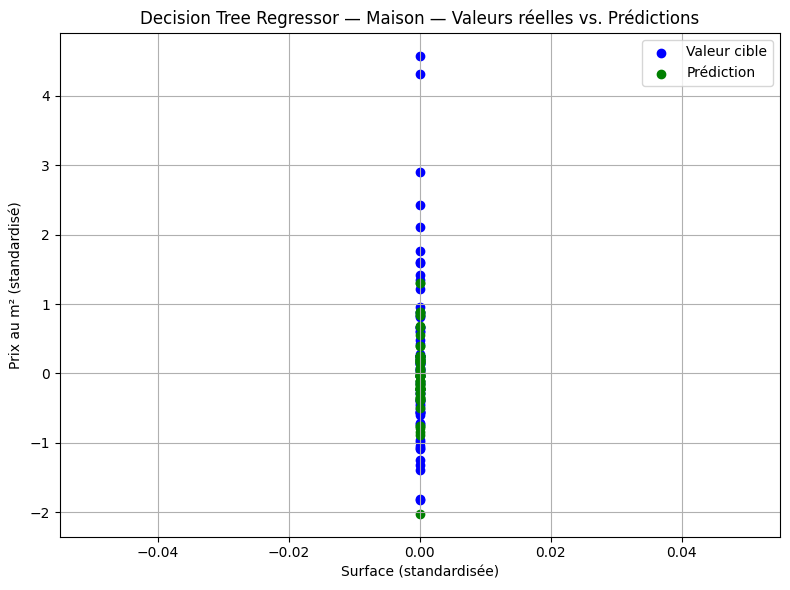

In [32]:
evaluate_and_plot("Decision Tree Regressor — Maison", model_tree_maison, X_test_scaled_tree_maison, y_test_scaled_tree_maison)

## Decision Tree Regressor— Appartement


📊 Decision Tree Regressor — Appartement — Évaluation du modèle :
MSE  : 1.1738
RMSE : 1.0834
R²   : -4.9767


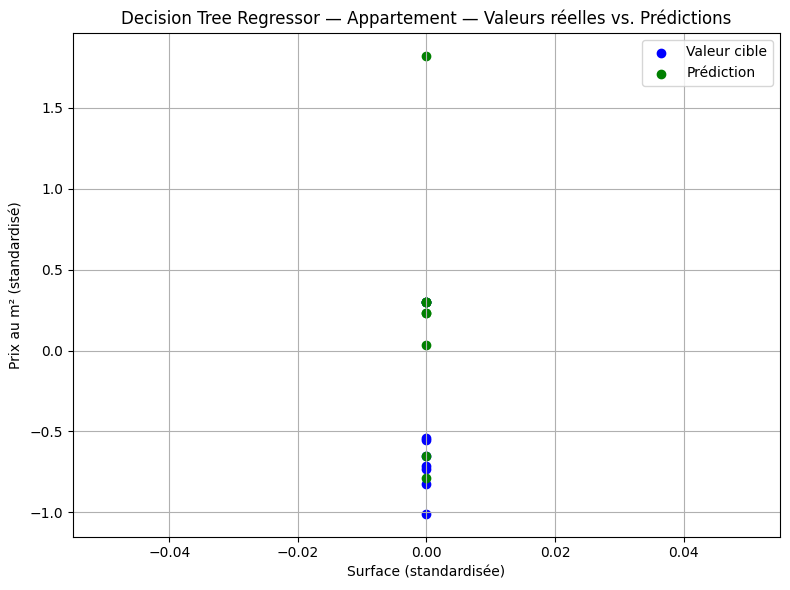

In [33]:
evaluate_and_plot("Decision Tree Regressor — Appartement", model_tree_apart, X_test_scaled_tree_apart, y_test_scaled_tree_apart)

## Random Forest Regressor — Appartement


📊 Random Forest Regressor — Maison — Évaluation du modèle :
MSE  : 1.7398
RMSE : 1.3190
R²   : -0.2083


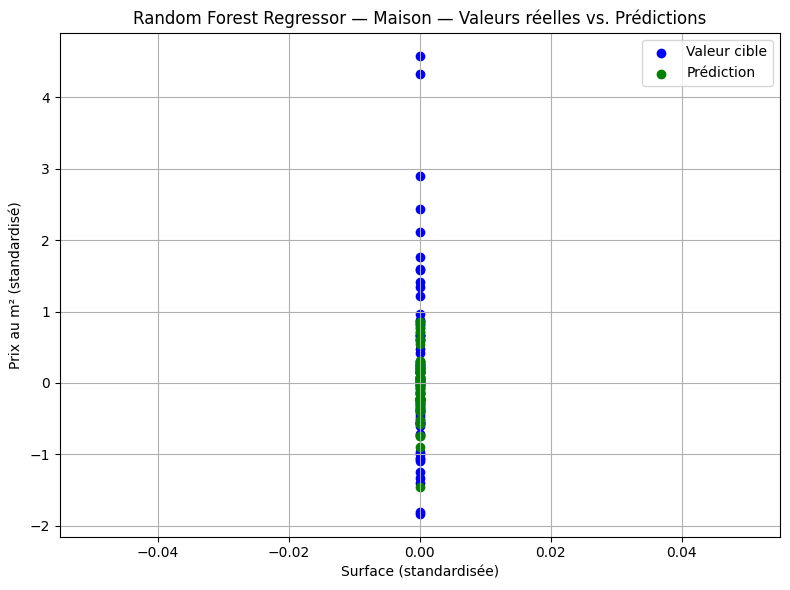

In [34]:
evaluate_and_plot("Random Forest Regressor — Maison", model_forest_maison, X_test_scaled_forest_maison, y_test_scaled_forest_maison)

## Random Forest Regressor — Appartement


📊 Random Forest Regressor — Appartement — Évaluation du modèle :
MSE  : 1.1261
RMSE : 1.0612
R²   : -4.7339


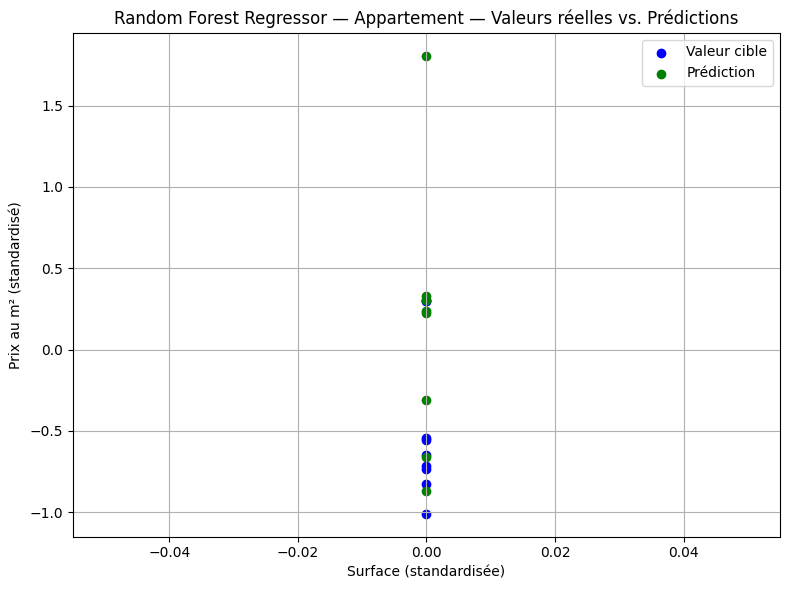

In [35]:
evaluate_and_plot("Random Forest Regressor — Appartement", model_forest_apart, X_test_scaled_forest_apart, y_test_scaled_forest_apart)

In [41]:
import os
import joblib
import numpy as np

# Cas où on est dans un notebook ou script
racine_courante = os.getcwd()
racine_projet = os.path.abspath(os.path.join(racine_courante, ".."))

# Construction du chemin vers les données
chemin = os.path.join(racine_projet,"models")

# Vérification du dossier
if not os.path.exists(chemin):
    raise FileNotFoundError(f"Le dossier suivant est introuvable : {chemin}")

# Fichiers attendus
fichiers = {
    "modèle": "random_forest_regressor_maison.pkl",
    "scaler_X": "random_forest_regressor_maison_scaler_X.pkl",
    "scaler_y": "random_forest_regressor_maison_scaler_y.pkl"
}

# Chargement
for nom, fichier in fichiers.items():
    complet = os.path.join(chemin, fichier)
    if not os.path.exists(complet):
        raise FileNotFoundError(f"Fichier manquant : {complet}")

modele = joblib.load(os.path.join(chemin, fichiers["modèle"]))
scaler_X = joblib.load(os.path.join(chemin, fichiers["scaler_X"]))
scaler_y = joblib.load(os.path.join(chemin, fichiers["scaler_y"]))

# Exemple de bien à prédire
surface = 120
nb_lots = 20
entree = np.array([[nb_lots, surface]])

# Prédiction
entree_scaled = scaler_X.transform(entree)
pred_scaled = modele.predict(entree_scaled)
prix_m2 = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0][0]

# Calcul du prix total
prix_total = prix_m2 * surface

# Affichage
print(f"✅ Prix prédit au m² : {prix_m2:,.2f} €")
print(f"🏠 Prix total estimé pour {surface} m² et {nb_lots} lot(s) : {prix_total:,.2f} €")

✅ Prix prédit au m² : 3,603.57 €
🏠 Prix total estimé pour 120 m² et 20 lot(s) : 432,428.56 €


In [38]:
import os
import joblib
import numpy as np

# Cas où on est dans un notebook ou script
racine_courante = os.getcwd()
racine_projet = os.path.abspath(os.path.join(racine_courante, ".."))

# Construction du chemin vers les données
chemin = os.path.join(racine_projet,"models")

# Vérification du dossier
if not os.path.exists(chemin):
    raise FileNotFoundError(f"Le dossier suivant est introuvable : {chemin}")

# Fichiers attendus
fichiers = {
    "modèle": "random_forest_regressor_apart.pkl",
    "scaler_X": "random_forest_regressor_apart_scaler_X.pkl",
    "scaler_y": "random_forest_regressor_apart_scaler_y.pkl"
}

# Chargement
for nom, fichier in fichiers.items():
    complet = os.path.join(chemin, fichier)
    if not os.path.exists(complet):
        raise FileNotFoundError(f"Fichier manquant : {complet}")

modele = joblib.load(os.path.join(chemin, fichiers["modèle"]))
scaler_X = joblib.load(os.path.join(chemin, fichiers["scaler_X"]))
scaler_y = joblib.load(os.path.join(chemin, fichiers["scaler_y"]))

# Exemple de bien à prédire
surface = 35.5
nb_lots = 2
entree = np.array([[nb_lots, surface]])

# Prédiction
entree_scaled = scaler_X.transform(entree)
pred_scaled = modele.predict(entree_scaled)
prix_m2 = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0][0]

# Calcul du prix total
prix_total = prix_m2 * surface

# Affichage
print(f"✅ Prix prédit au m² : {prix_m2:,.2f} €")
print(f"🏠 Prix total estimé pour {surface} m² et {nb_lots} lot(s) : {prix_total:,.2f} €")

✅ Prix prédit au m² : 8,128.22 €
🏠 Prix total estimé pour 35.5 m² et 2 lot(s) : 288,551.65 €
